In [ ]:
# requests 설치

# !pip install requests

In [ ]:
# 패키지 준비

import io
import zipfile
import requests
import pandas as pd
import numpy as np

In [ ]:
# 데이터 준비

JENA_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

def download_jena_climate() -> pd.DataFrame:
    """Jena Climate 데이터셋을 다운로드하여 DataFrame으로 반환 (약 420,000행)"""
    response = requests.get(JENA_URL, timeout=60)
    response.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(response.content)) as zf:   # zip: 압축풀기 
        csv_name = [n for n in zf.namelist() if n.endswith(".csv")][0]
        with zf.open(csv_name) as f:
            df = pd.read_csv(f)
    return df

df = download_jena_climate()
# df = pd.read_csv('data-files/jena_climate_2009_2016.csv.zip') # 이미 다운로드한 파일 있으면 실행할 코드
print(df.shape)          # (420551, 15)  ← "Date Time" 컬럼 + 14개 기상 변수
print(df.columns.tolist())
# ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
#  'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)',
#  'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

# 10분 간격 → 1시간 간격으로 리샘플링 (6개 중 1개만 취함) — 데이터 크기와 노이즈를 동시에 줄임
df_hourly = df.iloc[5::6].reset_index(drop=True) # 1시간 데이터가 6개 들어오고, 마지막 시간의 데이터만 가져오려면 [5:]로 5번째 이후부터 가져오면 된다
print(df_hourly.shape)   # (70092, 15)

FEATURE_COLUMNS = [
    "p (mbar)", "T (degC)", "Tpot (K)", "Tdew (degC)", "rh (%)",
    "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "sh (g/kg)",
    "H2OC (mmol/mol)", "rho (g/m**3)", "wv (m/s)", "max. wv (m/s)", "wd (deg)",
]
TARGET_COLUMN = "T (degC)"

values = df_hourly[FEATURE_COLUMNS].values.astype(np.float32)   # (70092, 14)
target_idx = FEATURE_COLUMNS.index(TARGET_COLUMN)
print(values.shape, "타깃 컬럼 인덱스:", target_idx)


(420551, 15)
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
(70091, 15)
(70091, 14) 타깃 컬럼 인덱스: 1


In [4]:
# 순환 신경망을 
import numpy as np

WINDOW_SIZE = 24  # 과거 24시간(하루)을 보고 다음 1시간 뒤 기온을 예측

def create_multivariate_windows(data: np.ndarray, target_idx: int, window_size: int):
    """
    data: (전체 시점 수, 특징 수) 형태의 다변량 시계열
    반환: X: (샘플 수, window_size, 특징 수), y: (샘플 수,)  ← y는 target_idx 컬럼의 다음 값
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size, :])          # 모든 14개 특징을 그대로 입력으로 사용
        y.append(data[i + window_size, target_idx])       # 타깃은 기온 컬럼 하나만
    return np.array(X), np.array(y)

X, y = create_multivariate_windows(values, target_idx, WINDOW_SIZE)
print(X.shape, y.shape)   # (70068, 24, 14) (70068,)   ← input_size가 1이 아니라 14가 됨에 주목


(70067, 24, 14) (70067,)


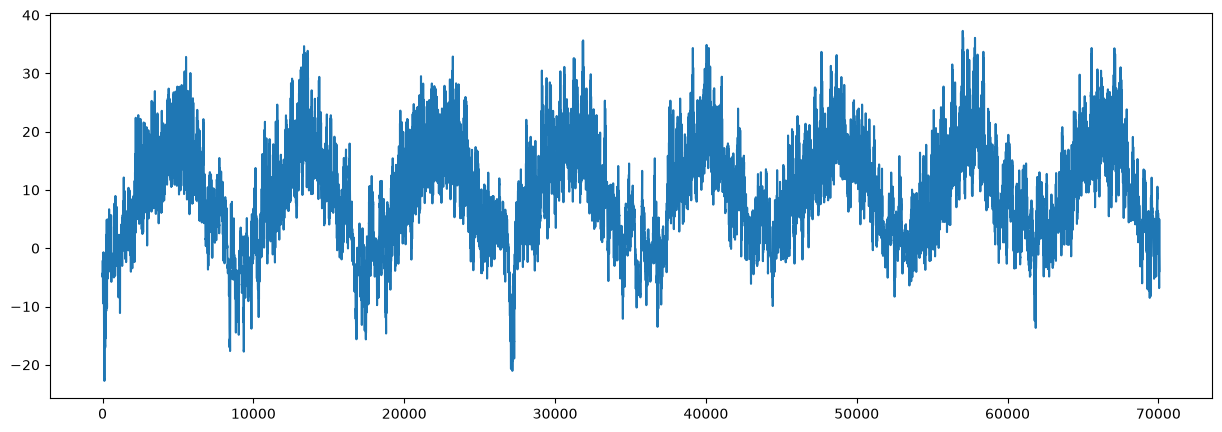

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y)
plt.show()

In [13]:
# 데이터 정규화

from sklearn.preprocessing import StandardScaler

n = len(X)
n_train, n_val = int(n * 0.7), int(n * 0.85)

# 스케일러는 (시점, 특징) 2차원 형태로 훈련 구간 원본 시계열에 fit — 윈도우 이전 시점의 raw 값 기준
train_raw = values[:int(len(values) * 0.7)]
scaler = StandardScaler() # 평균 0, 표준편차 1인 분포로 정규화
scaler.fit(train_raw)   # 14개 컬럼 각각의 평균/표준편차를 개별적으로 학습

# scaled = scaler.transform(train_raw)
# scaled.mean(axis=0)
# scaled.std(axis=0)

def scale_windows(X_windows):
    shape = X_windows.shape                              # (N, window, 14)
    flat = X_windows.reshape(-1, shape[-1])               # (N*window, 14)
    scaled = scaler.transform(flat)
    return scaled.reshape(shape)

X_scaled = scale_windows(X)

# 타깃(y)도 동일한 스케일러의 기온 컬럼 통계로 정규화 (역변환 시 사용)
y_mean, y_std = scaler.mean_[target_idx], scaler.scale_[target_idx]
y_scaled = (y - y_mean) / y_std # 입력 X에서 학습한 온도의 평균과 표준편차를 이용해서 y값도 정규화

X_train, y_train = X_scaled[:n_train], y_scaled[:n_train]
X_val, y_val = X_scaled[n_train:n_val], y_scaled[n_train:n_val]
X_test, y_test = X_scaled[n_val:], y_scaled[n_val:]
print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")


train=49046  val=10510  test=10511


In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,  # 단일 층이면 dropout 무의미
        )
        self.fc = nn.Linear(hidden_size, 1)  # 마지막 은닉 상태 → 다음 값 1개 예측

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]   # 마지막 시점의 은닉 상태만 사용 (batch, hidden_size) -> (배치, 시퀀스, 출력값)
        return self.fc(last_hidden)         # (batch, 1)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class MultivariateTimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)          # 이미 (N, window, 14) 형태 — unsqueeze 불필요
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MultivariateTimeSeriesDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(MultivariateTimeSeriesDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(MultivariateTimeSeriesDataset(X_test, y_test), batch_size=64, shuffle=False)




In [15]:
import torch
import torch.nn as nn

class LSTMForecaster(nn.Module):
    def __init__(self, input_size=14, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,  # 단일 층이면 dropout 무의미
        )
        self.fc = nn.Linear(hidden_size, 1)  # 마지막 은닉 상태 → 다음 값 1개 예측

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]   # 마지막 시점의 은닉 상태만 사용 (batch, hidden_size) -> (배치, 시퀀스, 출력값)
        return self.fc(last_hidden)         # (batch, 1)


# 4-5절의 LSTMForecaster를 그대로 재사용 — input_size만 14로 지정하면 끝
# (nn.LSTM은 input_size를 생성자 인자로 받으므로 모델 코드 수정이 전혀 필요 없습니다)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMForecaster(input_size=len(FEATURE_COLUMNS), hidden_size=64, num_layers=2).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"총 파라미터 수: {n_params:,}")  # 단변량(CO2) 모델보다 입력 게이트 파라미터가 14배 늘어 소폭 증가

총 파라미터 수: 53,825


In [17]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        # RNN 계열은 기울기 폭주 방지를 위해 클리핑을 관례적으로 적용
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

In [18]:
# 훈련 설계 및 훈련

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

best_val_loss = float("inf")
patience, patience_counter = 10, 0

for epoch in range(1, 51):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = eval_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_lstm_jena.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Epoch {epoch}: 조기 종료")
            break

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:3d}] train_loss={train_loss:.5f}  val_loss={val_loss:.5f}")

# 4-6절과 동일한 방식으로 정규화를 되돌려 실제 섭씨(°C) 단위 RMSE 계산
model.load_state_dict(torch.load("best_lstm_jena.pt"))
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    pred_scaled = model(X_test_t).cpu().numpy().reshape(-1)

pred_celsius = pred_scaled * y_std + y_mean
true_celsius = y_test * y_std + y_mean

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(true_celsius, pred_celsius))
print(f"Jena 기온 예측 RMSE: {rmse:.3f} °C")


[Epoch   1] train_loss=0.03639  val_loss=0.00905
[Epoch   5] train_loss=0.00831  val_loss=0.00864
[Epoch  10] train_loss=0.00739  val_loss=0.00785
[Epoch  15] train_loss=0.00726  val_loss=0.00736
[Epoch  20] train_loss=0.00686  val_loss=0.00734
[Epoch  25] train_loss=0.00673  val_loss=0.00711
[Epoch  30] train_loss=0.00648  val_loss=0.00746
[Epoch  35] train_loss=0.00647  val_loss=0.00699
[Epoch  40] train_loss=0.00640  val_loss=0.00694
[Epoch  45] train_loss=0.00630  val_loss=0.00700
Epoch 48: 조기 종료
Jena 기온 예측 RMSE: 0.641 °C
